# Text Analysis of Martial Arts-related Subreddits

The purpose of this project is to analyse the differences and similarities between different subreddits existing around a common topic, in this case martial arts. At first, I will collect Reddit data, analyse TF-IDF scores, and attempt to classify the subreddits using k-means and Naive Bayes algorithms. Then, I will introduce networks to visualise connections between threaded comments and users. Finally, I will make use of embeddings to further the analysis.

## I/ Collecting Reddit Data and Exploring TF-IDF Results

In [1]:
# Setup autoreload
%load_ext autoreload
%autoreload 2

# Create README.md 
# pip3 install nbconvert
# jupyter nbconvert --execute --to markdown MartialArtsRedditAnalysis.ipynb
# then rename to README.md

In [35]:
from reddit_helper import *
import os
import pyarrow
import pickle

Let's first collect  50 posts from the r/MuayThai, r/bjj, r/MMA, and r/Boxing subreddits, and display some of their initial characteristics. This is done using the `RedditScraper` class created in the `reddit_helper.py` file. 

In [3]:
# Example subreddits
subreddits = ['MuayThai', 'bjj', 'MMA', 'Boxing']

# Establish cache directory
CACHE_DIR = os.path.join(os.getcwd(), 'data')

# Analysis parameters
MAX_TERMS = 1000
MIN_DOC_FREQ = 2
TOP_N = 10
# LIMIT = 50 Initial limit at 50 for testing
LIMIT = 500
USERNAME = "matteolarrode"

# Initialize scraper
scraper = RedditScraper(
user_agent=f"SDS_textanalysis/1.0 (by /u/{USERNAME})"
)

# Analyze each subreddit independently
results = {}
submissions = {}

for subreddit in subreddits:
    print(f"\nAnalyzing r/{subreddit}...")

    # Define the cache file path for this subreddit
    cached_file = os.path.join(CACHE_DIR, f"{subreddit}_data.pkl")

    # If the data for the subreddit is already cached, no need to collect
    if os.path.exists(cached_file):
        # Load data from cache
        print(f"Loading cached data for r/{subreddit}...")
        with open(cached_file, 'rb') as file:
            submissions[subreddit] = pickle.load(file)
    
    # Otherwise, collect posts and cache them
    else:
        submissions[subreddit] = scraper.get_subreddit_posts(subreddit, limit=LIMIT)
        with open(cached_file, 'wb') as file:
            pickle.dump(submissions[subreddit], file)

    # Analyze subreddit
    results[subreddit] = analyze_subreddit(
        submissions[subreddit],
        max_terms=MAX_TERMS,   # Maximum number of terms to keep
        min_doc_freq=MIN_DOC_FREQ,   # Term must appear in at least min_doc_freq documents
        top_n_terms=TOP_N # Number of top terms returned in result
    )

    # Print results for this subreddit
    print(f"\nVocabulary Statistics for r/{subreddit}:")
    print(f"Total words: {results[subreddit]['vocab_stats']['total_words']}")
    print(f"Unique words: {results[subreddit]['vocab_stats']['unique_words']}")
    print(f"Words appearing ≥{MIN_DOC_FREQ} times: {results[subreddit]['vocab_stats']['words_min_freq']}")
    print(f"Coverage by top {MAX_TERMS} words: {results[subreddit]['vocab_stats']['coverage_top_1000']:.2f}%")
    print(f"Matrix shape: {results[subreddit]['matrix_shape']}")
    print(f"Matrix sparsity: {results[subreddit]['matrix_sparsity']:.2f}%")

    print(f"\nTop {TOP_N} terms by TF-IDF score:")
    print(results[subreddit]['top_terms'][['term', 'score']].to_string())


Analyzing r/MuayThai...
Loading cached data for r/MuayThai...

Vocabulary Statistics for r/MuayThai:
Total words: 38142
Unique words: 5155
Words appearing ≥2 times: 2384
Coverage by top 1000 words: 82.93%
Matrix shape: (500, 1000)
Matrix sparsity: 97.76%

Top 10 terms by TF-IDF score:
         term     score
860      thai  0.051784
527      muay  0.050555
266     fight  0.042132
388        im  0.035211
932        vs  0.030987
560       one  0.029892
907  training  0.025881
454      like  0.025353
776  sparring  0.022809
307       get  0.022165

Analyzing r/bjj...
Loading cached data for r/bjj...

Vocabulary Statistics for r/bjj:
Total words: 46080
Unique words: 5572
Words appearing ≥2 times: 2717
Coverage by top 1000 words: 83.23%
Matrix shape: (500, 1000)
Matrix sparsity: 97.37%

Top 10 terms by TF-IDF score:
       term     score
91      bjj  0.045379
387      im  0.037150
465    like  0.033840
306      gi  0.029001
331   guard  0.027802
303     get  0.027212
337     gym  0.026797
8

Let's try to grasp a better understanding of the data structure of the `results` object. It is a dictionary with the following keys:


In [4]:
print(results['MuayThai'].keys())
print(results['MuayThai']['vocab_stats'].keys())

dict_keys(['vocab_stats', 'freq_distribution', 'top_terms', 'vectorizer', 'matrix_shape', 'matrix_sparsity'])
dict_keys(['total_words', 'unique_words', 'words_min_freq', 'coverage_top_1000'])


- `vocab_stats` is itself a dictionary which contains some statistics on the vocabulary present in the posts of the subreddit.
- `top_terms` returns a number of the top terms by TF-IDF defined by the `TOP_N` constant.

Also, the code has been written so that the first time it is run to query the posts of a subreddit, the data is cached in `/data` for later use as a `pickle` file (`/data` is in the .gitignore). Note that `.pkl` files can only be read in Python.

### Some exploratory data analysis

First, I will **plot keywords over time**. Each post is a dictionary, and its creation Unix timestamp is associated to te `created_utc` key. 

In [5]:
print(f"Keys of each post: {submissions['MuayThai'][0].keys()}")

Keys of each post: dict_keys(['approved_at_utc', 'subreddit', 'selftext', 'author_fullname', 'saved', 'mod_reason_title', 'gilded', 'clicked', 'title', 'link_flair_richtext', 'subreddit_name_prefixed', 'hidden', 'pwls', 'link_flair_css_class', 'downs', 'thumbnail_height', 'top_awarded_type', 'hide_score', 'name', 'quarantine', 'link_flair_text_color', 'upvote_ratio', 'author_flair_background_color', 'subreddit_type', 'ups', 'total_awards_received', 'media_embed', 'thumbnail_width', 'author_flair_template_id', 'is_original_content', 'user_reports', 'secure_media', 'is_reddit_media_domain', 'is_meta', 'category', 'secure_media_embed', 'link_flair_text', 'can_mod_post', 'score', 'approved_by', 'is_created_from_ads_ui', 'author_premium', 'thumbnail', 'edited', 'author_flair_css_class', 'author_flair_richtext', 'gildings', 'content_categories', 'is_self', 'mod_note', 'created', 'link_flair_type', 'wls', 'removed_by_category', 'banned_by', 'author_flair_type', 'domain', 'allow_live_comments'

In [12]:
print(submissions['MuayThai'][0]['selftext'])
print(submissions['MuayThai'][0]['created_utc'])

Hey guys. I need to cut 2.5-3kg (5.5lbs) in 10 days. Im running everyday, im on caloric deficit and im gonna cut water in last 2/3 days. Any other tips? I've heard about keto and throwing out carbs.
1730323742.0


Using helper functions created in `reddit_helper.py`, I create a `DataFrame` with each post, their text, creation date and the counts and term-frequencies of their top-terms.

In [39]:
top_terms = results['MuayThai']['top_terms']['term'].tolist()  # Extract top terms

word_freq_muaythai_df = process_posts(submissions['MuayThai'], 'MuayThai', top_terms)

word_freq_muaythai_df.columns


Index(['post_id', 'created_utc_unix', 'created_date', 'thai_count', 'thai_tf',
       'muay_count', 'muay_tf', 'fight_count', 'fight_tf', 'im_count', 'im_tf',
       'vs_count', 'vs_tf', 'one_count', 'one_tf', 'training_count',
       'training_tf', 'like_count', 'like_tf', 'sparring_count', 'sparring_tf',
       'get_count', 'get_tf', 'total_word_count'],
      dtype='object')

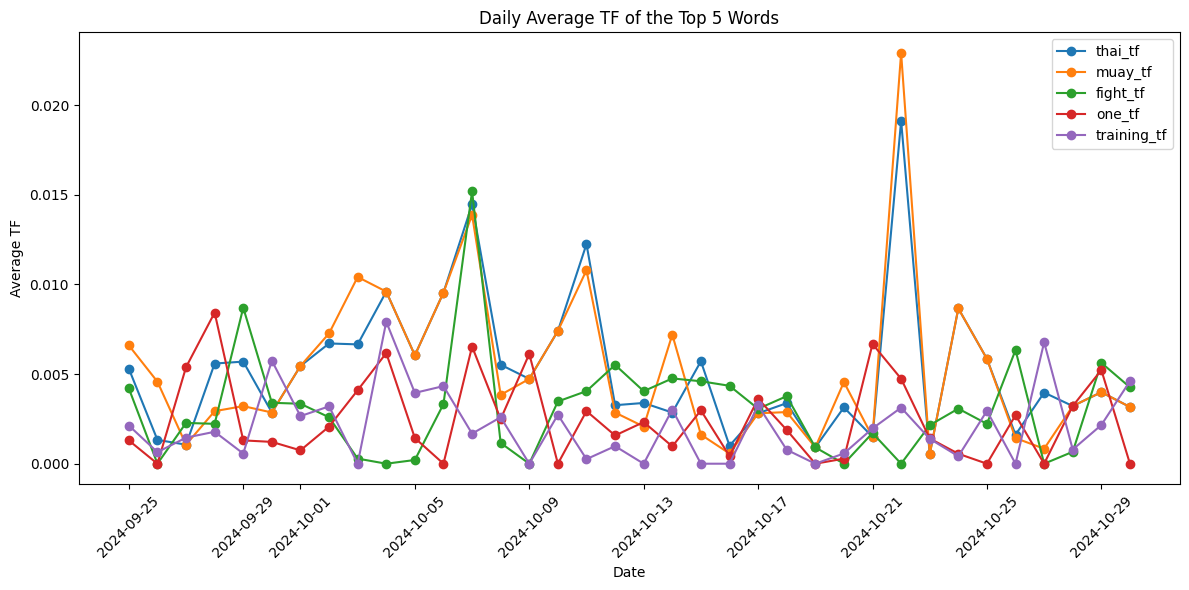

In [34]:
def plot_top_words_freq():
    # Convert 'created_date' to datetime
    word_freq_muaythai_df['created_date'] = pd.to_datetime(word_freq_muaythai_df['created_date'])

# Extract date for daily aggregation
    word_freq_muaythai_df['date'] = word_freq_muaythai_df['created_date'].dt.date

# Calculate the daily average TF for the first five words
    tf_columns = ['thai_tf', 'muay_tf', 'fight_tf', 'one_tf', 'training_tf']
    daily_average_tf = word_freq_muaythai_df.groupby('date')[tf_columns].mean().reset_index()

# Plotting
    plt.figure(figsize=(12, 6))
    for word in tf_columns:
        plt.plot(daily_average_tf['date'], daily_average_tf[word], marker='o', label=word)

    plt.title('Daily Average TF of the Top 5 Words')
    plt.xlabel('Date')
    plt.ylabel('Average TF')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_top_words_freq()

4. **Table the most common URLs for stories**. Triangulate these plots with a table summarising the top news outlets for this sub in this time period. Notice the starter code to process this from the posts data that has been stored in a large `submissions` dictionary. Note, this code does not turn all the `json` into a DataFrame, but extracts only the URL column and processes that. It also uses a _regular expression_ to separate out the top level domain, which may or may not be the most robust.  
5. **Write a summary**. Solely for reflection at this point, write some intuitions that you discover with this exploration. 


In [ ]:
# Data Exploration: 
submissions['MuayThai'][0] # Example post from the MuayThai subreddit

url_list = [post['url'] for post in submissions['MuayThai']]
url_df = pd.DataFrame(url_list, columns=['url'])
url_df['domain'] = url_df['url'].str.extract(r'(https?://[^/]+)')

url_df['domain'].value_counts().head(10)